# Modeling

## Imports

In [1]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.append('../src')

In [2]:
import numpy
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, RocCurveDisplay, precision_recall_curve

In [3]:
train_df = pd.read_csv('../data/processed/train.csv', delimiter=',')
test_df = pd.read_csv('../data/processed/test.csv', delimiter=',')

FileNotFoundError: [Errno 2] No such file or directory: '../data/processed/train.csv'

## quick data check

after preprocessing we have:
- train.csv - has the target column SeriousDlqin2yrs
- test.csv - no target column, we submit predictions to kaggle and get auc score back

features i added in preprocessing:
- MonthlyDebt = DebtRatio * MonthlyIncome
- TotalLatePayments = sum of all three late payment columns

In [ ]:
print(f"Train shape: {train_df.shape}")
print(f"Test shape:  {test_df.shape}")

assert train_df.shape[1] == test_df.shape[1]+1, "There is an error in columns count!"

Train shape: (149999, 13)
Test shape:  (101503, 12)


### making sure test doesnt have target

In [ ]:
target = 'SeriousDlqin2yrs'

assert target in train_df.columns, 'Target is missing in train!'
assert target not in test_df.columns, 'Target is in test! Data leakage possible!'

### separating features and target

In [ ]:
X = train_df.drop(columns=[target])
y = train_df[target]

X_test = test_df

## Modeling strategy

i'll train 3 different classifiers to see which type fits best:
- logistic regression - simple linear model, good as a baseline
- random forest - ensemble, handles outliers well
- gradient boosting - usually best accuracy but slowest and more hyperparams to tune


### Cross-validation

Cross-validation will be used to basically compare models on training data before kaggle do this (on real test data). I'll split training data into k-folds (5 in this case) and then average the auc score from models.

### Scaler

- StandardScaler

The most common scaler at the start, scales data to make average = 0 and std = 1


### Class imbalance

Target is in 7% positive so i'll use class_weight='balanced' in all models (weights minority class ~13x more automatically)

### Pipeline

Models are put in Pipeline (scaler + model) so the scaler only sees train folds during cross-validation, not the whole dataset (it avoids the leakage)

### StratifiedKFold

So each fold keeps the same 7/93 ratio as the full dataset, and AUC-ROC as metric since accuracy would be misleading here (model could just always predict 0 and get 93%)

In [ ]:
cross_validation = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

Random Forest and GBM don't need StandardScaler as they are immune of scale

## Models used in this project

In [ ]:
models = {
  "Logistic Regression": Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(
      class_weight='balanced',
      max_iter=1000,
      random_state=42
    ))
  ]),
  "Random Forest": Pipeline([
    ("clf", RandomForestClassifier(
      n_estimators=100, # number of trees
      class_weight='balanced',
      random_state=42,
      n_jobs=-1
    ))
  ]),
  "Gradient Boosting Machine": Pipeline([
    ("clf", GradientBoostingClassifier(
      n_estimators=100, # number of trees
      random_state=42
    ))
  ]),
  "XGBoost": Pipeline([
    ("clf", XGBClassifier(
      scale_pos_weight = 13
    ))
  ])
}


In [ ]:
results = {}

for name, pipeline in models.items():
  scores = cross_val_score(
    pipeline, X, y,
    cv=cross_validation,
    scoring='roc_auc',
    n_jobs=-1
  )
  results[name] = scores
  print(f"{name:25s} AUC: {scores.mean():.4f} +- {scores.std():.4f}")

Logistic Regression       AUC: 0.7905 +- 0.0054
Random Forest             AUC: 0.8364 +- 0.0061
Gradient Boosting Machine AUC: 0.8646 +- 0.0037
XGBoost                   AUC: 0.8490 +- 0.0025


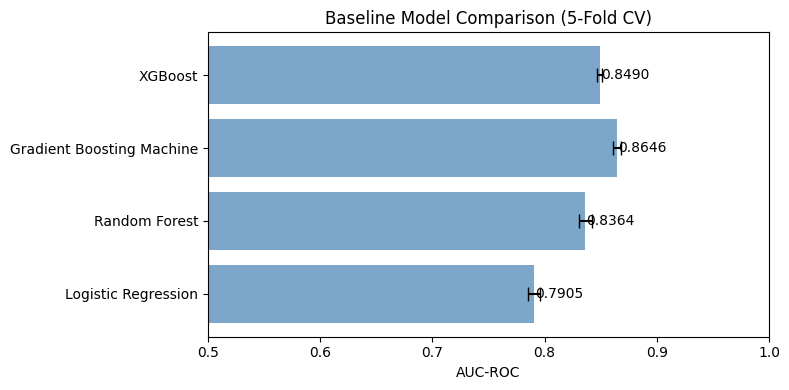

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))

for name, scores in results.items():
  ax.barh(name, scores.mean(), xerr=scores.std(), 
    capsize=5, color='steelblue', alpha=0.7)
  ax.text(scores.mean() + 0.001, 
    list(results.keys()).index(name), 
    f"{scores.mean():.4f}", va='center')

ax.set_xlabel('AUC-ROC')
ax.set_title('Baseline Model Comparison (5-Fold CV)')
ax.set_xlim(0.5, 1.0)
plt.tight_layout()
plt.show()

In [ ]:
# Usually GBM or RF wins baseline — adjust model name if needed
best_baseline_name = max(results, key=lambda k: results[k].mean())
print(f"Best baseline model: {best_baseline_name} "
  f"(AUC: {results[best_baseline_name].mean():.4f})")

# Parameter grid for Gradient Boosting
# (adjust if Random Forest won)
param_dist_gb = {
  'clf__n_estimators':  [100, 200, 300],
  'clf__max_depth':     [3, 4, 5],
  'clf__learning_rate': [0.01, 0.05, 0.1],
  'clf__subsample':     [0.8, 1.0],   # fraction of samples per tree
}

# Note: prefix 'clf__' is required by Pipeline
# Pipeline routes 'clf__param' to the 'clf' step

search = RandomizedSearchCV(
  models["Gradient Boosting Machine"],
  param_distributions=param_dist_gb,
  n_iter=20,           # try 20 random combinations
  cv=cross_validation,
  scoring='roc_auc',
  n_jobs=-1,
  random_state=42,
  verbose=1            # prints progress
)

search.fit(X, y)

print(f"\nBest params:  {search.best_params_}")
print(f"Best AUC:     {search.best_score_:.4f}")

Best baseline model: Gradient Boosting Machine (AUC: 0.8646)
Fitting 5 folds for each of 20 candidates, totalling 100 fits

Best params:  {'clf__subsample': 0.8, 'clf__n_estimators': 300, 'clf__max_depth': 5, 'clf__learning_rate': 0.05}
Best AUC:     0.8656
